# ICS-Sniper detector quick start

This notebook runs one complete experiment: input checks, benign validation, attack detection, evaluation, and alert plotting. Network captures are already transcribed to IPAL, so no PCAP transcription is performed.

5 scenarios: 1 Process delay attack on S-EN-BASE, 2 UF-Depletion attack on S-EN-BASE, 3 Process delay attack on H-MD-BASE, 4 Process delay attack on H-MD-LOSS, and 5 Process delay attack on H-MD-LOSS-EXT.

Select one S-number in the next cell.

In [1]:
# Select one scenario (S1-S5).
SCENARIO = 3

if SCENARIO not in range(1, 6):
    raise ValueError("SCENARIO must be an integer from 1 to 5.")

## Resolve the selected experiment

The mapping below records the training dataset and tuned configuration family used by each original experiment. All paths are resolved from the repository root.

In [2]:
from pathlib import Path
import json
import os
import random
import re
import shlex
import shutil
import subprocess
import tempfile

SCENARIOS = {
    1: {"description": "Process delay attack on S-EN-BASE", "train_dir": "20251111", "family": "tuned_enip"},
    2: {"description": "UF-Depletion attack on S-EN-BASE", "train_dir": "20251111", "family": "tuned_enip"},
    3: {"description": "Process delay attack on H-MD-BASE", "train_dir": "20260411-clean", "family": "base"},
    4: {"description": "Process delay attack on H-MD-LOSS", "train_dir": "20260411", "family": "tuned"},
    5: {"description": "Process delay attack on H-MD-LOSS-EXT", "train_dir": "20260504", "family": "tuned"},
}

ROOT = Path.cwd().resolve()
if ROOT.name == "utils":
    ROOT = ROOT.parent
if not (ROOT / "dataset").is_dir() or not (ROOT / "config").is_dir():
    raise RuntimeError("Start Jupyter from the repository root before running this notebook.")

DATASET_ROOT = ROOT / "dataset"
UTILS = ROOT / "utils"
META = SCENARIOS[SCENARIO]
ATTACK_DATA_DIR = DATASET_ROOT / f"scenario-{SCENARIO}-attack"
CONFIG_DIR = ROOT / "config" / "quick_start" / f"S{SCENARIO}"
TRAIN_DIR = DATASET_ROOT / META["train_dir"]
SCENARIO_DIR = UTILS / f"scenario-{SCENARIO}-attack" / "quick_start_result"
VALIDATION_DIR = SCENARIO_DIR / "validation"
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
MATPLOTLIB_CACHE = Path(tempfile.gettempdir()) / "ics-sniper-detection-matplotlib"
MATPLOTLIB_CACHE.mkdir(exist_ok=True)
SUBPROCESS_ENV = os.environ.copy()
SUBPROCESS_ENV["MPLCONFIGDIR"] = str(MATPLOTLIB_CACHE)
SUBPROCESS_ENV["MPLBACKEND"] = "Agg"

def tool(name):
    local = ROOT / "ipal-dev" / "bin" / name
    resolved = local if local.exists() else shutil.which(name)
    if not resolved:
        raise FileNotFoundError(f"{name} is unavailable. Run setup_development_venv.sh and activate_ipal.sh first.")
    return str(resolved)

IIDS = tool("ipal-iids")
EVALUATE = tool("ipal-evaluate")
PLOT_ALERTS = tool("ipal-plot-alerts")
ATTACK_JSONS = sorted(ATTACK_DATA_DIR.glob("[0-9]*_attacks.json"))
if len(ATTACK_JSONS) != 1:
    raise RuntimeError(f"Expected one numbered attack JSON in {ATTACK_DATA_DIR}, found {len(ATTACK_JSONS)}.")
ATTACK_JSON = ATTACK_JSONS[0]
print(f"Selected S{SCENARIO}: {META['description']}")
print(f"Training data: {TRAIN_DIR.relative_to(ROOT)}")
print(f"Attack data: {ATTACK_DATA_DIR.relative_to(ROOT)}")
print(f"Attack JSON: {ATTACK_JSON.relative_to(ROOT)}")
print(f"Results: {SCENARIO_DIR.relative_to(ROOT)}")

Selected S3: Process delay attack on H-MD-BASE
Training data: dataset/20260411-clean
Attack data: dataset/scenario-3-attack
Attack JSON: dataset/scenario-3-attack/1_attacks.json
Results: utils/scenario-3-attack/quick_start_result


## Build detector jobs and check inputs

Validation uses two different benign runs. Attack detection retrains on the selected training data and evaluates against the scenario ground truth.

In [3]:
def config_name(stem):
    suffix = {"base": "", "tuned": "_tuned", "tuned_enip": "_tuned_enip"}[META["family"]]
    return CONFIG_DIR / f"{stem}{suffix}.config"

ensemble_config = CONFIG_DIR / ("all.config" if META["family"] == "base" else "all_tuned.config")
NETWORK_JOBS = [
    ("IaT-mean", config_name("iat_mean"), None, "IaT-mean.ipal.gz"),
    ("IaT-range", config_name("iat_range"), None, "IaT-range.ipal.gz"),
    ("Kitsune", config_name("kitsune"), None, "Kitsune.ipal.gz"),
    ("Any", ensemble_config, CONFIG_DIR / "combiner-Any.config", "Any.ipal.gz"),
    ("All", ensemble_config, CONFIG_DIR / "combiner-All.config", "All.ipal.gz"),
]
STATE_JOBS = [
    ("Histogram", config_name("histogram"), None, "Histogram.state.gz"),
    ("MinMax", config_name("minmax"), None, "MinMax.ipal.gz"),
    ("SteadyTime", config_name("steadytime"), None, "SteadyTime.state.gz"),
    ("InvariantRules", config_name("ir_1s"), None, "InvariantRules.ipal.gz"),
    ("PASAD", config_name("pasad"), None, "PASAD.ipal.gz"),
    ("Any", CONFIG_DIR / "all_p.config", CONFIG_DIR / "combiner-Any.config", "Any.state.gz"),
    ("All", CONFIG_DIR / "all_p.config", CONFIG_DIR / "combiner-All_p.config", "All.state.gz"),
]

network_train_files = sorted(
    (p for p in TRAIN_DIR.glob("tun-*.ipal.gz") if re.fullmatch(r"tun-\d+\.ipal\.gz", p.name)),
    key=lambda p: int(re.search(r"\d+", p.name).group()),
)
state_train_files = sorted(
    (p for p in TRAIN_DIR.glob("*.state.gz") if re.fullmatch(r"\d+\.state\.gz", p.name)),
    key=lambda p: int(p.name.split(".")[0]),
)
NETWORK_ATTACK = ATTACK_DATA_DIR / f"S{SCENARIO}_att.ipal.gz"
STATE_ATTACK = ATTACK_DATA_DIR / f"S{SCENARIO}_att.state.gz"
state_full_training = TRAIN_DIR / "full_training.state.gz"

required = [ATTACK_JSON, NETWORK_ATTACK, STATE_ATTACK, state_full_training, *[j[1] for j in NETWORK_JOBS], *[j[1] for j in STATE_JOBS], *[j[2] for j in NETWORK_JOBS + STATE_JOBS if j[2]]]
missing = sorted({str(p.relative_to(ROOT)) for p in required if not p.exists()})
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))
if len(network_train_files) < 2 or len(state_train_files) < 2:
    raise RuntimeError("At least two benign message and state runs are required for validation.")

### Set the input parameters

In [4]:
NETWORK_TRAIN, NETWORK_VALID = random.sample(network_train_files, 2)
STATE_TRAIN, STATE_VALID = random.sample(state_train_files, 2)
print(f"Message validation: train={NETWORK_TRAIN.name}, live={NETWORK_VALID.name}")
print(f"State validation: train={STATE_TRAIN.name}, live={STATE_VALID.name}")
print(f"Attack inputs: {NETWORK_ATTACK.name}, {STATE_ATTACK.name}")

Message validation: train=tun-7.ipal.gz, live=tun-9.ipal.gz
State validation: train=6.state.gz, live=8.state.gz
Attack inputs: S3_att.ipal.gz, S3_att.state.gz


The random selections above are used only for benign validation. The lowest tuned network-detector false-positive rates were obtained with the following training inputs (indices are zero-based positions in `network_train_files`):

- S1: `dataset/20251111/tun-2.ipal.gz` — `network_train_files[1]`
- S2: `dataset/20251111/tun-2.ipal.gz` — `network_train_files[1]`
- S3: `dataset/20260411-clean/tun-11.ipal.gz` — `network_train_files[5]`
- S4: `dataset/20260411/tun-4.ipal.gz` — `network_train_files[0]`
- S5: `dataset/20260504/tun-2.ipal.gz` — `network_train_files[1]`

In [5]:
optimal_network_train_index = {1: 1, 2: 1, 3: 5, 4: 0, 5: 1}
NETWORK_TRAIN_DETECT = network_train_files[optimal_network_train_index[SCENARIO]]
print(f"Message attack detection: train={NETWORK_TRAIN_DETECT.name}")

Message attack detection: train=tun-11.ipal.gz


## Execution helpers

Every command is printed before it runs. A non-zero exit status stops the notebook immediately.

In [ ]:
def run(command):
    # print("\n$ " + shlex.join(map(str, command)))
    subprocess.run([str(part) for part in command], cwd=UTILS, env=SUBPROCESS_ENV, check=True)

def run_detector(job, modality, train_input, live_input, output_dir, attacks=None):
    label, config, combiner, output_name = job
    output = output_dir / output_name
    logfile = output_dir / f"{modality}-{label}.log"
    evaluation = output_dir / f"{modality}-{label}.eval.json"
    command = [
        IIDS, "--retrain", "--config", config,
        f"--train.{modality}", train_input,
        f"--live.{modality}", live_input,
        "--log", "INFO", "--logfile", logfile, "--output", output,
    ]
    if combiner:
        command.extend(["--combiner.config", combiner])
    print(f"\n{'=' * 16} {label} {'=' * 16}")
    run(command)
    eval_command = [EVALUATE, output, "--output", evaluation]
    if attacks:
        eval_command.extend(["--attacks", attacks])
    run(eval_command)
    return output

def run_suite(jobs, modality, train_input, live_input, output_dir, attacks=None):
    output_dir.mkdir(exist_ok=True)
    return [run_detector(job, modality, train_input, live_input, output_dir, attacks) for job in jobs]

## 1. Train and validate on benign data

Each detector is trained on one benign run and evaluated on a different benign run. These outputs are kept separate from the attack results.

In [ ]:
network_validation_outputs = run_suite(
    NETWORK_JOBS, "ipal", NETWORK_TRAIN, NETWORK_VALID, VALIDATION_DIR
)
state_validation_outputs = run_suite(
    STATE_JOBS, "state", STATE_TRAIN, STATE_VALID, VALIDATION_DIR
)

## 2. Retrain and detect the selected attack

The message detectors use the scenario-specific benign IPAL input that produced the lowest tuned false-positive rate. State detectors use the complete benign state training file.

In [7]:
network_attack_outputs = run_suite(
    NETWORK_JOBS, "ipal", NETWORK_TRAIN_DETECT, NETWORK_ATTACK, SCENARIO_DIR, ATTACK_JSON
)
state_attack_outputs = run_suite(
    STATE_JOBS, "state", state_full_training, STATE_ATTACK, SCENARIO_DIR, ATTACK_JSON
)


================ IaT-mean ================

================ IaT-range ================

================ Kitsune ================

================ Any ================

================ All ================

================ Histogram ================

================ MinMax ================

================ SteadyTime ================

================ InvariantRules ================

================ PASAD ================

================ Any ================

================ All ================


## 3. Plot detector alerts

Message detectors use the common tick settings. State detectors use a minimum alert width of five seconds.

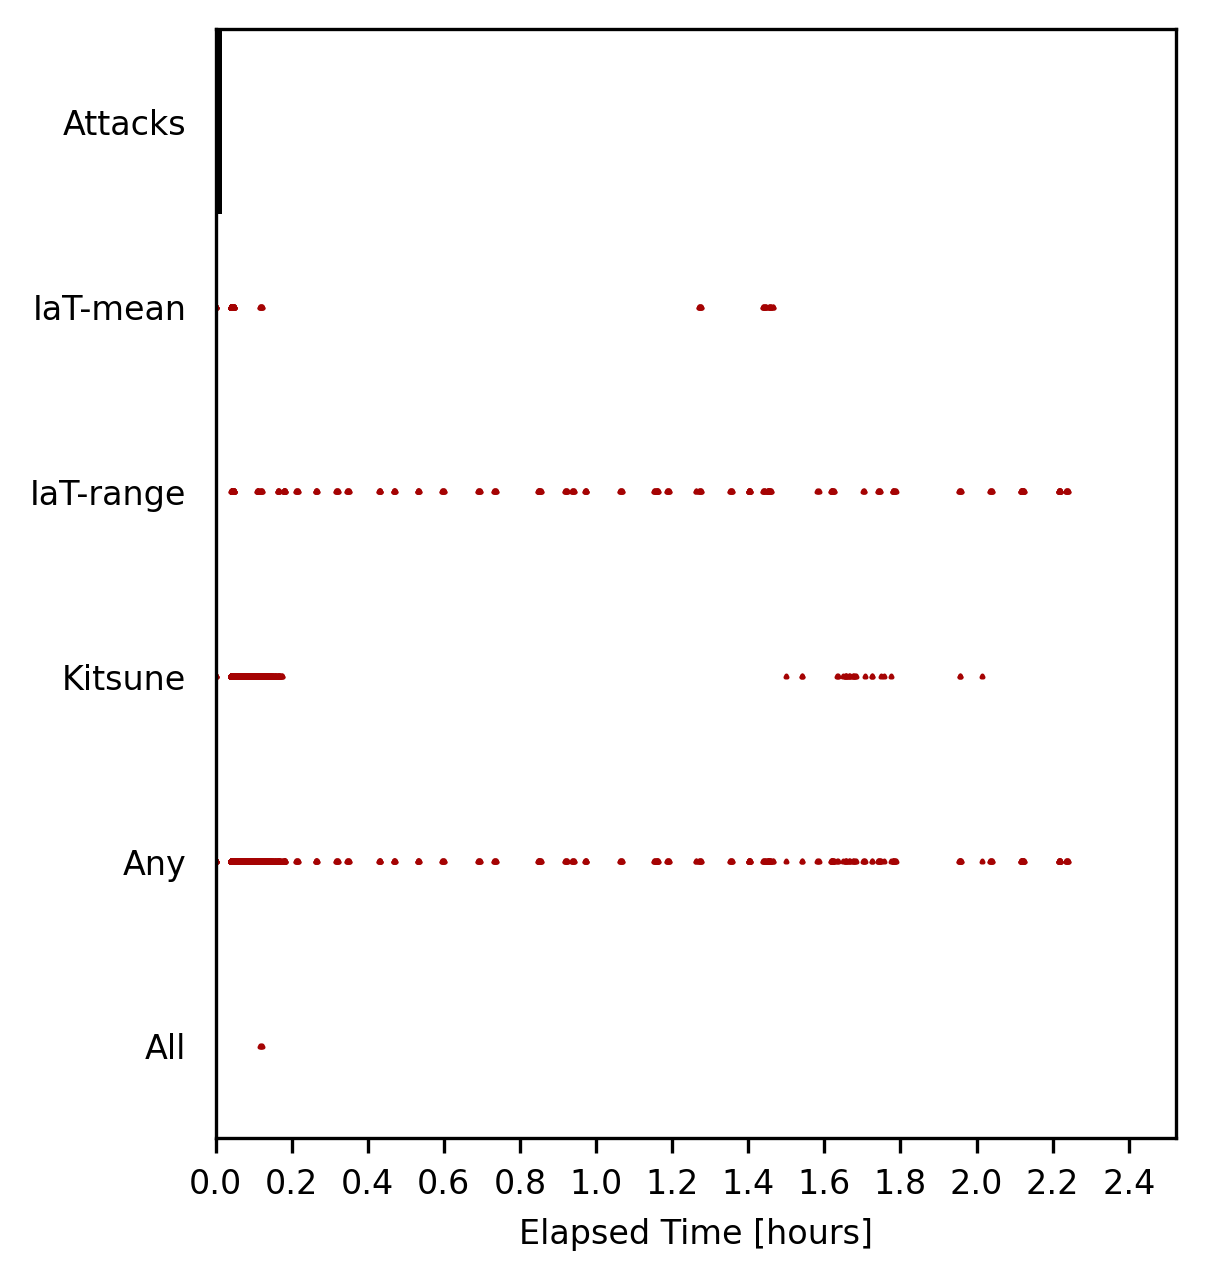

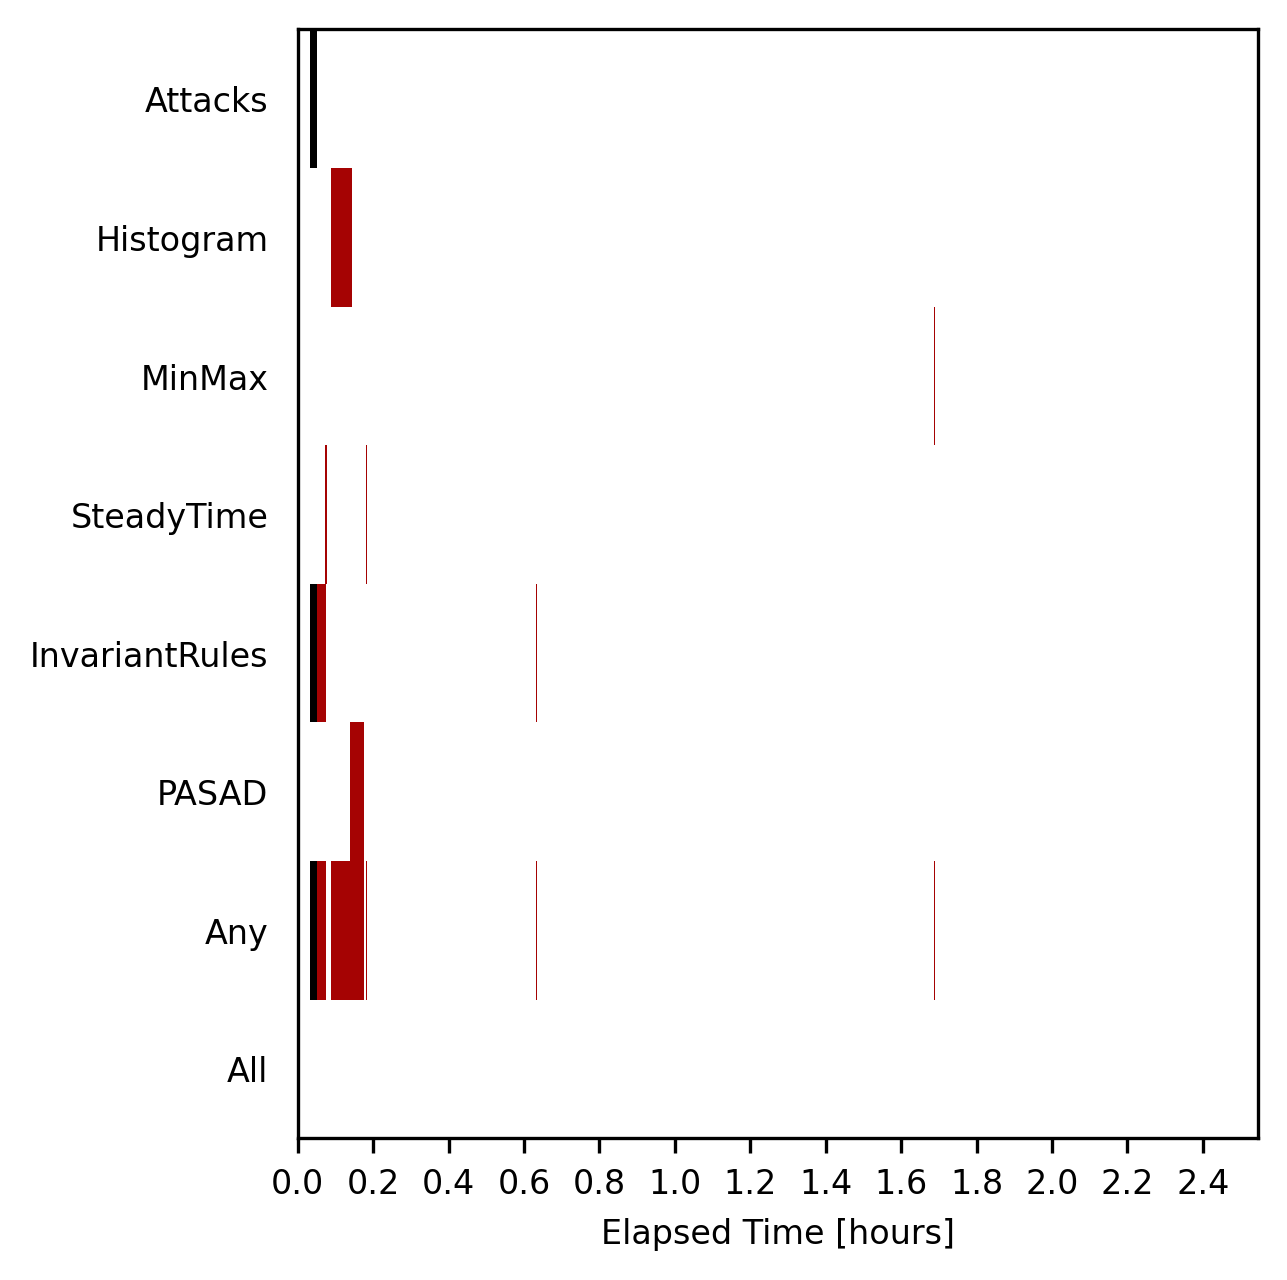

In [8]:
network_plot_inputs = [SCENARIO_DIR / job[3] for job in NETWORK_JOBS]
state_plot_inputs = [SCENARIO_DIR / job[3] for job in STATE_JOBS]
missing_plot_inputs = [path for path in network_plot_inputs + state_plot_inputs if not path.exists()]
if missing_plot_inputs:
    missing_names = ", ".join(path.name for path in missing_plot_inputs)
    raise FileNotFoundError(f"Run the attack-detection cell first. Missing plot inputs: {missing_names}")

network_plot = SCENARIO_DIR / f"S{SCENARIO}-networkDetectors.png"
state_plot = SCENARIO_DIR / f"S{SCENARIO}-stateDetectors.png"
run([
    PLOT_ALERTS, "--attacks", ATTACK_JSON, *network_plot_inputs,
    "--output", network_plot, "--mark-fp", "--draw-ticks", "--tick-size", "0.2",
])
run([
    PLOT_ALERTS, "--attacks", ATTACK_JSON, *state_plot_inputs,
    "--output", state_plot, "--mark-fp", "--min-width", "5",
])

from IPython.display import Image, display
display(Image(filename=str(network_plot)))
display(Image(filename=str(state_plot)))